# Model Explainability

The objective of this notebook is to interpret the machine learning results and identify the clinical biomarkers that contribute most strongly to pancreatic cancer detection.
Explainability is particularly important in healthcare applications because it helps translate predictive performance into clinically meaningful insights.

## Data Loading

The pancreatic cancer dataset is loaded and prepared for explainability analysis.

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/pancreatic_600_risk123.csv")

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X = df[
    [
        "age",
        "plasma_C",
        "creatinine",
        "LYVE1",
        "REG1B",
        "TFF1",
        "REG1A",
        "CA19_9",
        "CEA",
        "bilirubin",
        "glucose",
        "urine_volume",
        "urine_pH"
    ]
]

y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(
    X_train_scaled,
    y_train
)


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

## Logistic Regression Coefficients

The magnitude of the standardized logistic regression coefficients is used to identify the biomarkers that contribute most strongly to model predictions.

In [9]:
coef_df = pd.DataFrame(
    log_reg.coef_.T,
    index=X.columns,
    columns=[
        "Healthy",
        "Benign",
        "Cancer"
    ]
)

coef_df

,Healthy,Benign,Cancer
age,-0.120865,0.024713,0.096152
plasma_C,-1.417389,-0.116343,1.533732
creatinine,-0.530279,-0.069258,0.599537
LYVE1,-1.150565,0.012702,1.137863
REG1B,-1.614490,0.086206,1.528284
TFF1,-1.080311,-0.020853,1.101164
REG1A,-1.928876,0.389616,1.539260
CA19_9,-0.378234,-0.720771,1.099004
CEA,-0.771468,-0.226478,0.997946
bilirubin,-1.224613,0.009068,1.215545


In [10]:
cancer_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coef_df["Cancer"].abs()
})

cancer_importance = (
    cancer_importance
    .sort_values(
        by="Coefficient",
        ascending=False
    )
)

cancer_importance

,Feature,Coefficient
REG1A,REG1A,1.539260
plasma_C,plasma_C,1.533732
REG1B,REG1B,1.528284
bilirubin,bilirubin,1.215545
LYVE1,LYVE1,1.137863
TFF1,TFF1,1.101164
CA19_9,CA19_9,1.099004
CEA,CEA,0.997946
creatinine,creatinine,0.599537
urine_volume,urine_volume,0.226017


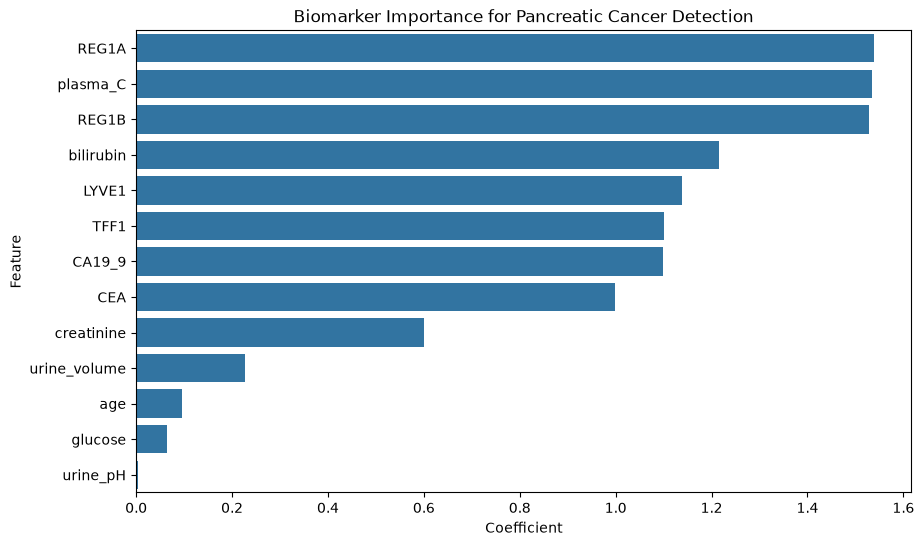

In [11]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=cancer_importance,
    x="Coefficient",
    y="Feature"
)

plt.title(
    "Biomarker Importance for Pancreatic Cancer Detection"
)

plt.show()

The same biomarkers consistently emerged as the most relevant variables across exploratory analysis, statistical validation and machine learning modelling.
This consistency strengthens confidence in the clinical relevance of REG1A, REG1B, CA19-9, TFF1 and CEA as potential indicators of pancreatic cancer.

## Comparison with Random Forest Feature Importance

The biomarkers identified by Logistic Regression are compared with the Random Forest feature importance rankings obtained during the modelling stage.

### Findings

Several biomarkers consistently appeared among the most influential predictors across both Logistic Regression and Random Forest models.
REG1A, REG1B, CA19-9, CEA and TFF1 were repeatedly identified as the strongest contributors to pancreatic cancer classification.
The consistency of these findings across different modelling approaches increases confidence in their potential clinical relevance.

## Conclusions

Model explainability analysis revealed that a small group of biomarkers contributes most strongly to pancreatic cancer detection.
REG1A, REG1B, CA19-9, CEA and TFF1 consistently emerged as the most influential features across multiple stages of the project, including exploratory analysis, statistical validation and predictive modelling.

These findings suggest that machine learning models can not only achieve high predictive performance but also provide clinically interpretable insights into the biological factors associated with pancreatic cancer diagnosis.